<a href="https://colab.research.google.com/github/Monish-ch/Deep-Learning/blob/main/labexp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Clear previous models
tf.keras.backend.clear_session()

# Fix random seed
np.random.seed(21)
tf.random.set_seed(21)

# AND Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=np.float32)

y = np.array([
    [0],
    [0],
    [0],
    [1]
], dtype=np.float32)

# Function to create neural network
def create_model(loss_function):

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(2,)),
        tf.keras.layers.Dense(
            5,
            activation='sigmoid'
        ),
        tf.keras.layers.Dense(
            1,
            activation='sigmoid'
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.008
        ),
        loss=loss_function,
        metrics=['accuracy']
    )

    return model

# -----------------------------
# Model A (MSE)
# -----------------------------
model_mse = create_model("mean_squared_error")

history_mse = model_mse.fit(
    X,
    y,
    epochs=1200,
    verbose=0
)

# -----------------------------
# Model B (BCE)
# -----------------------------
tf.random.set_seed(21)

model_bce = create_model("binary_crossentropy")

history_bce = model_bce.fit(
    X,
    y,
    epochs=1200,
    verbose=0
)

# -----------------------------
# Evaluation
# -----------------------------
loss_mse, acc_mse = model_mse.evaluate(
    X,
    y,
    verbose=0
)

loss_bce, acc_bce = model_bce.evaluate(
    X,
    y,
    verbose=0
)

print("Neural Network A (MSE)")
print("----------------------------------")
print(f"Loss     : {loss_mse:.4f}")
print(f"Accuracy : {acc_mse*100:.2f}%")

print()

print("Neural Network B (BCE)")
print("----------------------------------")
print(f"Loss     : {loss_bce:.4f}")
print(f"Accuracy : {acc_bce*100:.2f}%")

Neural Network A (MSE)
----------------------------------
Loss     : 0.0005
Accuracy : 100.00%

Neural Network B (BCE)
----------------------------------
Loss     : 0.0048
Accuracy : 100.00%


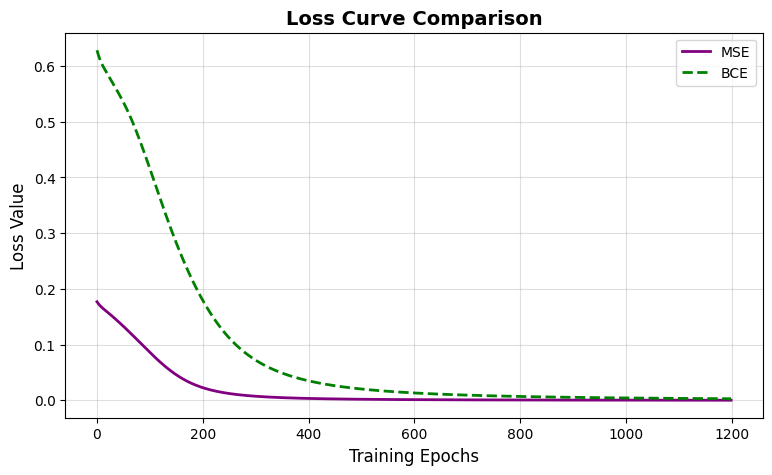

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(
    history_mse.history['loss'],
    color='purple',
    linewidth=2,
    label='MSE'
)

plt.plot(
    history_bce.history['loss'],
    color='green',
    linewidth=2,
    linestyle='--',
    label='BCE'
)

plt.title(
    "Loss Curve Comparison",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Training Epochs", fontsize=12)
plt.ylabel("Loss Value", fontsize=12)

plt.grid(alpha=0.4)
plt.legend()

plt.show()